In [16]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [17]:
x = torch.tensor([[1.0], [2.0], [3.0], [4.0], [5.0]], device=device)
y = torch.tensor([[5.0], [8.0], [11.0], [14.0], [17.0]], device=device)

x.shape, y.shape

(torch.Size([5, 1]), torch.Size([5, 1]))

In [18]:
w = torch.randn(1, 1, device=device, requires_grad=True)
b = torch.zeros(1, device=device, requires_grad=True)

w, b

(tensor([[0.1940]], device='cuda:0', requires_grad=True),
 tensor([0.], device='cuda:0', requires_grad=True))

In [19]:
learning_rate = 0.01
num_steps = 300
loss_history = []

for step in range(num_steps + 1):
    pred = x @ w + b
    loss = ((pred - y) ** 2).mean()

    if w.grad is not None:
        w.grad.zero_()
    if b.grad is not None:
        b.grad.zero_()

    loss.backward()

    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

    loss_history.append(loss.item())

w.item(), b.item(), loss_history[-1]

(3.113497257232666, 1.5902388095855713, 0.030769212171435356)

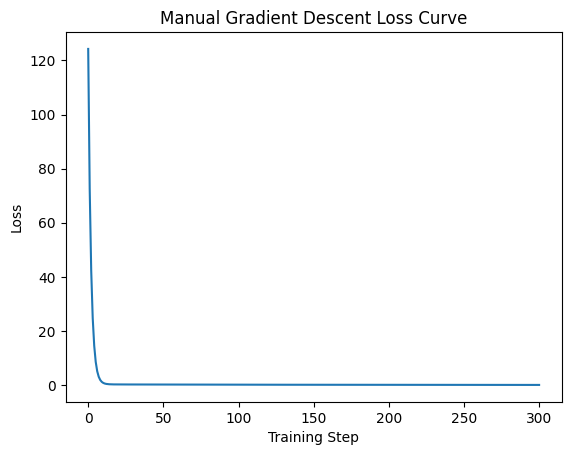

In [20]:
plt.figure()
plt.plot(loss_history)
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Manual Gradient Descent Loss Curve")
plt.show()

In [21]:
test_x = torch.tensor([[6.0], [7.0], [8.0]], device=device)

with torch.no_grad():
    test_pred = test_x @ w + b

test_pred

tensor([[20.2712],
        [23.3847],
        [26.4982]], device='cuda:0')